In [ ]:
from src.data_loader import load_data
from src.preprocess import prepare_data, print_vectorized_sample
from src.ML.train_NN import train_model, print_NN_input_sample, TextClassifier, DeepTextClassifier
from src.predict import predict_single_text
from src.analysis import  intra_category_similarity
from src.plotting import plot_confusion_matrix, plot_learning_curve, plot_metrics_bar_chart
from src.ML.train_svm import train_SVM
from src.ML.train_rf import train_random_forest

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
plt.rcParams["figure.figsize"] = (5,3)

DATA_PATH = "/home/xkubanova_126831/bakalarka/e_com_dataset/data/ecommerceDataset.csv"

In [2]:
# dataset structure:
# samples: 50 425
# categories: 4 (Househols, Electronics, Books, Clothing & Accessories)
# percentage: household: 38%, books: 24%, electronics: 21%, clothing & accessories: 17%

print("--- 1. Loading and Preparing Data ---")
df = load_data("/home/xkubanova_126831/bakalarka/e_com_dataset/data/ecommerceDataset.csv")


#prepare data
X_train, X_test, y_train, y_test, vectorizer = prepare_data(df)


--- 1. Loading and Preparing Data ---
Dataset shape: (50425, 2)

Categories samples:

Books:
  Inner Engineering: A Yogi's Guide to Joy About the Author Sadhguru Jaggi VasudevSADHGURU is a yogi, mystic, and visionary who established the Isha Foundation, a nonprofit dedicated to the cultivation of human potential. He belongs to no particular tradition, and his scientific methods for self-transformation have universal appeal. Sadhguru has been an in?uential voice at global forums including th...

Clothing & Accessories:
  Woopower 36M Pink for 024M Baby Trouser Top Sets3Pcs Boy Girl Hooded Topsstriped Pantshairband Outfits36Mpink Size name36m colourpink description100 brand new and type children setgender unisexfor season autumn springcoloroptional pink greensize table 7080 90 100cminchsize tops length bust pants length age70 32 1260 46 1811 37 1457 36m80 34 1339 48 1890 39 1535 612m90 36 1417 52 2047 41 1614 1218m...

Electronics:
  Dell 19.5V-3.34AMP 65W Laptop Adapter (Without power C

Simple Feed Forward NN

Training model: {model_class.__name__}
X_train Shape (samples, features): torch.Size([40340, 5000])
X_train Data Type: torch.float32
y_train Shape (labels): torch.Size([40340])
y_train Data Type: torch.int64
Feature Vector Length (input_dim): 5000
------------------------------
First sample (first 10 features):
[0.         0.         0.         0.         0.         0.
 0.04444515 0.         0.         0.        ]
------------------------------
Test accuracy: 0.9735
                        precision    recall  f1-score   support

                 Books     0.9794    0.9653    0.9723      2364
Clothing & Accessories     0.9804    0.9815    0.9810      1734
           Electronics     0.9707    0.9656    0.9681      2124
             Household     0.9685    0.9793    0.9739      3863

              accuracy                         0.9735     10085
             macro avg     0.9747    0.9729    0.9738     10085
          weighted avg     0.9736    0.9735    0.9735  

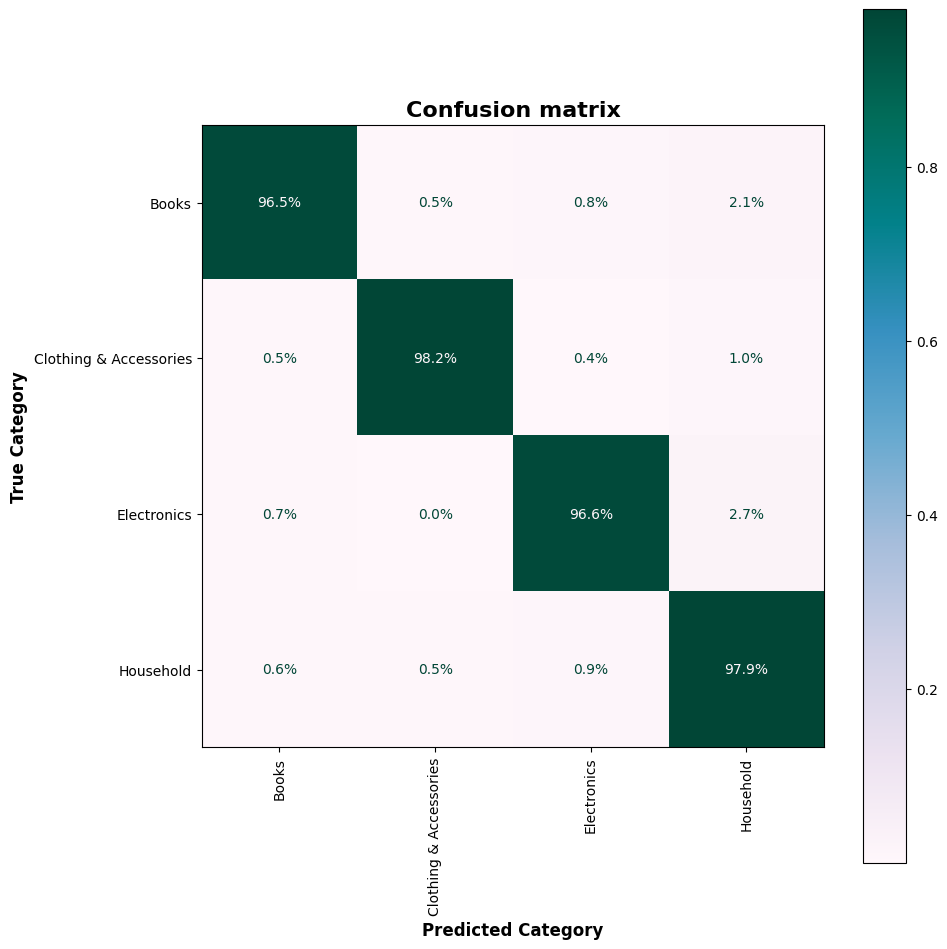

<Figure size 800x600 with 0 Axes>

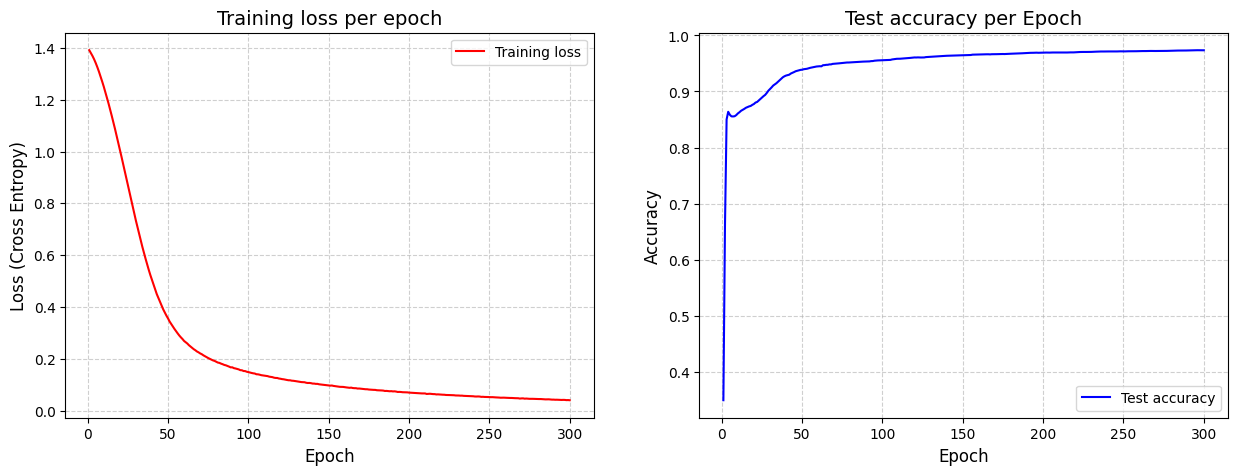

<Figure size 800x600 with 0 Axes>

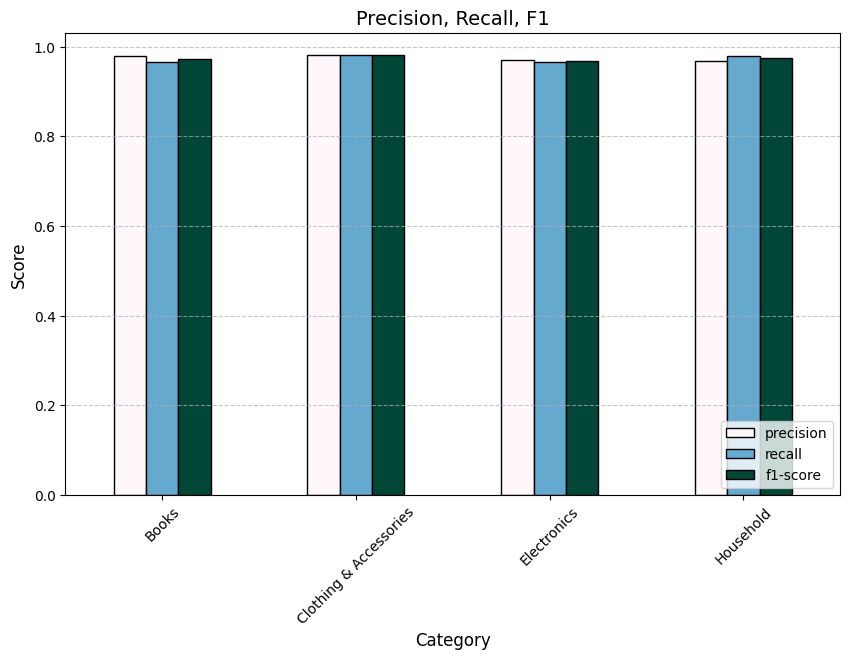

<Figure size 800x600 with 0 Axes>

In [3]:
from src.ML.train_NN import TextClassifier


print("Simple Feed Forward NN")

simple_model, class_to_idx, simple_acc = train_model(
    X_train, y_train, X_test, y_test,
    model_class=TextClassifier,
    model_params={"hidden_dim": 256},
    epochs=300,
    lr=0.001
)


In [ ]:
from src.ML.train_NN import DeepTextClassifier


print("Deep Feed Forward NN")

deep_model, class_to_idx, deep_acc = train_model(
    X_train, y_train, X_test, y_test,
    model_class=DeepTextClassifier,
    model_params={"hidden_dims": [512, 256, 128, 64]},
    epochs=150,
    lr=0.001
)


Deep Feed Forward NN

Training model: {model_class.__name__}
X_train Shape (samples, features): torch.Size([40340, 5000])
X_train Data Type: torch.float32
y_train Shape (labels): torch.Size([40340])
y_train Data Type: torch.int64
Feature Vector Length (input_dim): 5000
------------------------------
First sample (first 10 features):
[0.         0.         0.         0.         0.         0.
 0.04444515 0.         0.         0.        ]
------------------------------
